In [58]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import netket as nk
import numpy as np
import netket as nk
import jax
import jax.numpy as jnp
import jax.tree_util as tree
import jax.typing as jt
import matplotlib.pyplot as plt
import optax
from flax import nnx
from flax import linen as nn
from netket.operator import AbstractOperator
from netket.experimental.observable import Renyi2EntanglementEntropy
from tqdm import tqdm
from netket.jax import jacobian
from itertools import product
from typing import Callable, Sequence

In [59]:
# Definimos el espacio en el que vamos a trabajar
from netket.hilbert import Spin, DiscreteHilbert, TensorHilbert
N = 2
N_ancilla = 2

# Sistema principal: N espines 1/2
# Ancilla: N_ancilla espines 1/2
hi_system = nk.hilbert.Spin(s=1/2, N=N)
# Espacio total = spin ⊗ ancilla
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [60]:
# Importamos las matrices de Pauli y definimos el Hamiltoniano  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    # Estos operadores automáticamente son σ_x^i ⊗ I_R
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

In [61]:
# Función que emplea el swap trick para calcular la entropía de entrelazamiento
def renyi2_entropy_sampled(vstate, N, subsystem_sites, n_samples, key=0, debug=False):
    """
    Estima la entropía de entrelazamiento de Rényi-2 (S₂) mediante muestreo Monte Carlo
    usando el *swap trick*.

    Calcula:
        S₂ = -log( ⟨SWAP⟩ )

    donde ⟨SWAP⟩ es el valor esperado del operador swap que intercambia el subsistema
    `subsystem_sites` entre dos copias independientes del estado |ψ⟩.

    El valor esperado se estima estocásticamente a partir de muestras generadas con
    `vstate.sample`.

    Args:
        vstate : netket.vqs.MCState
            Estado variacional de NetKet que representa la función de onda |ψ⟩.

        N : int
            Número total de grados de libertad (spins/qubits).
            (Nota: actualmente no se usa explícitamente dentro de la función).

        subsystem_sites : array-like
            Índices de los sitios que definen el subsistema A.
            La entropía se calcula entre A y su complemento.

        n_samples : int
            Número de muestras Monte Carlo usadas para estimar ⟨SWAP⟩.
            Se generan 2 * n_samples configuraciones en total.

        key : int, optional
            Semilla para la permutación aleatoria de las muestras (JAX PRNG key).
            Default: 0.

        debug : bool, optional
            Si True, imprime información detallada sobre:
            - muestras generadas
            - configuraciones intercambiadas
            - valores medios de log |ψ|
            - estimación de ⟨SWAP⟩

    Returns:
       S2 : jax.numpy.DeviceArray
        Estimación Monte Carlo de la entropía de Rényi-2 del subsistema definido
        por `subsystem_sites`.

    """

    # Asegurar que subsystem_sites es un array de enteros
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)

    # Muestras
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    if debug:
      print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
      # print(f"All samples: " {all_samples})
      print(f"Samples1: {samples1}")
      print(f"Samples2: {samples2}")

    # Calcular el complementario
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)


    # Intercambio de subsistemas
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    if debug:
      print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
      print(f"Swapped1: {swapped1}")
      print(f"Swapped2: {swapped2}")

    # Log amplitudes de las configuraciones originales y permutadas
    log_psi_orig1 = vstate.log_value(samples1)
    log_psi_orig2 = vstate.log_value(samples2)
    log_psi_swap1 = vstate.log_value(swapped1)
    log_psi_swap2 = vstate.log_value(swapped2)
    if debug:
      # print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)), "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)))
      print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)).item(),  "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)).item())
      print("log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap1)).item(), "log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap2)).item())

    # ⟨SWAP⟩ = ⟨ψ(x')ψ(y') / [ψ(x)ψ(y)]⟩
    swap_ratio = jnp.exp((log_psi_swap1 + log_psi_swap2) - (log_psi_orig1 + log_psi_orig2))
    swap_exp = jnp.mean(swap_ratio)
    if debug:
      jax.debug.print("swap ratio = {}", jnp.round(swap_ratio, 4))
      print(f"⟨SWAP⟩ = {swap_exp.item()}")

    # Entropía de Rényi 2
    S2 = -jnp.log(jnp.abs(swap_exp))
    return S2

def renyi2_entropy_exact(vstate, subsystem_sites):
    """
    Calcula la entropía de Rényi-2 de forma exadta usando matriz densidad.
    
    S2 = -ln(Tr(ρ_A^2))
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
    """
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # Obtener vector de estado completo
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    # print(f"Sistema total: {N} qubits")
    # print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
    # print(f"Subsistema B: {n_B} qubits")
    # print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # Identificar qubits del complemento
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Reorganizar la base para tener (A, B) ordenados
    # Convertir {-1,+1} a {0,1} para indexar
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Crear índices para reorganizar
    # Queremos: primero los qubits de A, luego los de B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir cada configuración a un índice único
    # Índice = suma de 2^i * bit_i
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir el vector de estado en forma matricial |ψ⟩ → ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # Matriz densidad del sistema completo: ρ = |ψ⟩⟨ψ|
    # No necesitamos construirla explícitamente para la traza parcial
    
    # Traza parcial sobre B: ρ_A = Tr_B(|ψ⟩⟨ψ|)
    # ρ_A[i,j] = Σ_k ψ[i,k] ψ*[j,k]
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    
    # Verificar que es hermítica y normalizada
    # print(f"\n|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f} (debe ser 1)")
    # print(f"Tr(ρ_A) = {jnp.trace(rho_A):.6f} (debe ser 1)")
    hermiticity_error = jnp.max(jnp.abs(rho_A - jnp.conj(rho_A.T)))
    # print(f"Error hermiticidad: {hermiticity_error:.2e}")
    
    # Calcular ρ_A^2
    rho_A_squared = rho_A @ rho_A
    
    # Pureza y entropía de Rényi-2
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    # print(f"\nTr(ρ_A²) = {purity:.6f} (pureza)")
    # print(f"S2 = -ln(Tr(ρ_A²)) = {S2:.6f}")
    
    # Información adicional: autovalores de ρ_A
    eigenvalues = jnp.linalg.eigvalsh(rho_A)
    eigenvalues = jnp.sort(eigenvalues)[::-1]  # Ordenar descendente
    # print(f"\nAutovalores de ρ_A:")
    # for i, eig in enumerate(eigenvalues):
    #     if eig.real > 1e-10:  # Mostrar solo los significativos
    #         print(f"  λ_{i} = {eig.real:.6f}")
    
    # Entropía de von Neumann (para comparar)
    # S_vN = -Tr(ρ_A ln ρ_A) = -Σ λ_i ln(λ_i)
    eigenvalues_clean = jnp.where(eigenvalues > 1e-10, eigenvalues, 1)  # Evitar log(0)
    S_vN = -jnp.sum(eigenvalues * jnp.log(eigenvalues_clean)).real
    # print(f"\nS_vN (von Neumann) = {S_vN:.6f} (para comparar)")
    
    return S2, rho_A

def vstate_to_vector(vstate):
    """
    Convierte un vstate de NetKet a un vector de estado completo.
    
    Args:
        vstate: NetKet variational state
        
    Returns:
        state_vector: Vector completo normalizado (2^N dimensiones)
        basis_states: Configuraciones correspondientes a cada entrada
    """
    N = vstate.hilbert.size
    
    # Generar todas las configuraciones posibles
    # NetKet usa {-1, +1} para spins
    all_configs = jnp.array(list(product([-1, 1], repeat=N)))
    
    # Obtener amplitudes
    log_psi = vstate.log_value(all_configs)
    psi = jnp.exp(log_psi)
    
    # Normalizar
    norm = jnp.sqrt(jnp.sum(jnp.abs(psi)**2))
    state_vector = psi / norm
    
    return state_vector, all_configs

def renyi2_entropy_and_grad_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente, este ultimo utilizando
    el gradiente de la log-amplitud de las samples
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    
    # ============================================================
    # 1) MUESTREO
    # ============================================================
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    
    if debug:
        print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
    
    # ============================================================
    # 2) CREACIÓN DE CONFIGURACIONES SWAP
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    
    if debug:
        print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
    
    # ============================================================
    # 3) LOG-AMPLITUDES
    # ============================================================
    log_o1 = vstate.log_value(samples1)
    log_o2 = vstate.log_value(samples2)
    log_s1 = vstate.log_value(swapped1)
    log_s2 = vstate.log_value(swapped2)
    
    if debug:
        print(f"mean log|ψ(orig1)|: {jnp.mean(jnp.abs(log_o1)):.6f}")
        print(f"mean log|ψ(orig2)|: {jnp.mean(jnp.abs(log_o2)):.6f}")
        print(f"mean log|ψ(swap1)|: {jnp.mean(jnp.abs(log_s1)):.6f}")
        print(f"mean log|ψ(swap2)|: {jnp.mean(jnp.abs(log_s2)):.6f}")
    
    # ============================================================
    # 4) RATIO SWAP Y ENTROPÍA S₂
    # ============================================================
    R = jnp.exp((log_s1 + log_s2) - (log_o1 + log_o2))  
    R_mean = jnp.mean(R)
    S2 = -jnp.log(jnp.abs(R_mean))
    
    if debug:
        print(f"⟨SWAP⟩ = {R_mean:.6f}")
        print(f"S₂ = {S2:.6f}")
    
    # ============================================================
    # 5) GRADIENTES (O_θ = ∂_θ log ψ)
    # ============================================================
    O_o1 = jacobian(vstate._apply_fun, vstate.parameters, samples1,
                    model_state=vstate.model_state,
                    mode="real", dense=False)  
    
    O_o2 = jacobian(vstate._apply_fun, vstate.parameters, samples2,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    O_s1 = jacobian(vstate._apply_fun, vstate.parameters, swapped1,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    O_s2 = jacobian(vstate._apply_fun, vstate.parameters, swapped2,
                    model_state=vstate.model_state,
                    mode="real", dense=False)
    
    # ============================================================
    # 6) ΔO = O(x') + O(y') - O(x) - O(y)
    # ============================================================
    DeltaO = jax.tree_util.tree_map(
        lambda s1, s2, o1, o2: s1 + s2 - o1 - o2,
        O_s1, O_s2, O_o1, O_o2
    )
    
    # ============================================================
    # 7) ⟨R * ΔO⟩ (promedio ponderado por R)
    # ============================================================
    def weighted_average(leaf):
        """
        leaf: array de forma (n_samples, *param_shape)
        Calcula ⟨R * leaf⟩ promediando sobre axis=0
        """
        # Expandir R para broadcasting: (n_samples, 1, 1, ...)
        expanded_R = R.reshape(-1, *([1] * (leaf.ndim - 1)))
        return jnp.mean(expanded_R * leaf, axis=0)
    
    numerator = jax.tree_util.tree_map(weighted_average, DeltaO)
    
    # ============================================================
    # 8) ∂θ S₂ = - ⟨R ΔO⟩ / ⟨R⟩
    # ============================================================
    grad_S2 = jax.tree_util.tree_map(lambda x: -x / R_mean, numerator)
    
    if debug:
        # Calcular norma del gradiente para debug
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_entropy_and_grad_stable(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente de forma similar a "renyi2_entropy_and_grad_sampled"
    pero numéricamente estable (aún no funciona bien del todo)
    
    Usa logsumexp y diferenciación automática para evitar overflow/underflow.
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    
    # ============================================================
    # 1) MUESTREO - Dos conjuntos independientes
    # ============================================================
    rng = jax.random.PRNGKey(key)
    rng1, rng2 = jax.random.split(rng)
    
    samples1 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    samples2 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    
    # Asegurar mismo tamaño
    M = min(samples1.shape[0], samples2.shape[0])
    samples1 = samples1[:M]
    samples2 = samples2[:M]
    
    if debug:
        print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
    
    # ============================================================
    # 2) PREPARAR SITIOS
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    # Precomputar configuraciones swapeadas (no dependen de params)
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], 
                                samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], 
                                samples2[:, complement_sites]], axis=1)
    
    # ============================================================
    # 3) FUNCIÓN PARA CALCULAR ln P (PURITY) - VERSIÓN EFICIENTE
    # ============================================================
    def log_psi_fn(params, samples):
        """Helper para evaluar log ψ sin crear vstate temporal"""
        return vstate.model.apply(
            {'params': params}, 
            samples,
            mutable=False
        )
    
    def lnP_estimator(params):
        """
        Calcula ln P_A de forma numéricamente estable usando logsumexp.
        
        P_A = ⟨Q⟩ donde Q_k = |ψ(α',β)|² |ψ(α,β')|² / (|ψ(α,β)|² |ψ(α',β')|²)
        
        ln P_A = logsumexp(log Q_k) - ln M
        """
        # Log-amplitudes evaluadas directamente con el modelo
        log_o1 = log_psi_fn(params, samples1)
        log_o2 = log_psi_fn(params, samples2)
        log_s1 = log_psi_fn(params, swapped1)
        log_s2 = log_psi_fn(params, swapped2)
        
        # log Q_k para cada par de muestras k
        log_q_loc = (log_s1 + log_s2) - (log_o1 + log_o2)
        
        # logsumexp automáticamente maneja la estabilidad numérica
        lnP = jax.scipy.special.logsumexp(log_q_loc) - jnp.log(M)
        
        # Tomamos la parte real para asegurar que sea un número real
        return lnP.real
    
    # ============================================================
    # 4) CALCULAR S2 Y SU GRADIENTE
    # ============================================================
    # Primero calculamos S2
    lnP = lnP_estimator(vstate.parameters)
    S2 = -lnP  # S2 = -ln(P)
    
    # Gradiente usando diferenciación automática de JAX
    # JAX automáticamente calcula los pesos softmax al diferenciar logsumexp
    grad_lnP = jax.grad(lnP_estimator)(vstate.parameters)
    
    # Convertir gradiente de ln P a gradiente de S2
    # ∂S2/∂θ = -∂(ln P)/∂θ
    grad_S2 = jax.tree_util.tree_map(lambda g: -g, grad_lnP)
    
    # ============================================================
    # 5) DEBUG INFO
    # ============================================================
    if debug:
        # Calcular algunas métricas para verificación
        log_o1 = vstate.log_value(samples1)
        log_o2 = vstate.log_value(samples2)
        log_s1 = vstate.log_value(swapped1)
        log_s2 = vstate.log_value(swapped2)
        
        print(f"mean log|ψ(orig1)|: {jnp.mean(jnp.abs(log_o1)):.6f}")
        print(f"mean log|ψ(orig2)|: {jnp.mean(jnp.abs(log_o2)):.6f}")
        print(f"mean log|ψ(swap1)|: {jnp.mean(jnp.abs(log_s1)):.6f}")
        print(f"mean log|ψ(swap2)|: {jnp.mean(jnp.abs(log_s2)):.6f}")
        
        log_q_loc = (log_s1 + log_s2) - (log_o1 + log_o2)
        print(f"mean log Q: {jnp.mean(log_q_loc):.6f}")
        print(f"std log Q: {jnp.std(log_q_loc):.6f}")
        print(f"ln P = {lnP:.6f}")
        print(f"S₂ = {S2:.6f}")
        
        # Calcular norma del gradiente
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

def renyi2_grad_only_stable(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Calcula SOLO el gradiente de S2.
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    N = vstate.hilbert.size
    
    # Draw two independent replica batches
    samples1 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, N)
    samples2 = vstate.sample(n_samples=n_samples, n_discard_per_chain=1000).reshape(-1, N)
    
    # M = min(samples1.shape[0], samples2.shape[0])
    # samples1 = samples1[:M]
    # samples2 = samples2[:M]
    
    def lnP_estimator(params, sigma1, sigma2):
        # Split each replica into A and B
        alpha = sigma1[:, subsystem_sites]
        alpha_p = sigma2[:, subsystem_sites]
        
        all_sites = jnp.arange(N)
        complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
        beta = sigma1[:, complement_sites]
        beta_p = sigma2[:, complement_sites]
        
        # Swapped configurations
        sigma_a_p_b = jnp.concatenate([alpha_p, beta], axis=-1)
        sigma_a_b_p = jnp.concatenate([alpha, beta_p], axis=-1)
        
        def logpsi_batch(p, σ):
            return vstate.model.apply({"params": p}, σ)
        
        logpsi_ab = logpsi_batch(params, sigma1)
        logpsi_a_p_b_p = logpsi_batch(params, sigma2)
        logpsi_a_p_b = logpsi_batch(params, sigma_a_p_b)
        logpsi_a_b_p = logpsi_batch(params, sigma_a_b_p)
        
        # Factor 2.0 para log|ψ|²
        log_q_loc = 2.0 * (
            (logpsi_a_p_b.real + logpsi_a_b_p.real) - 
            (logpsi_ab.real + logpsi_a_p_b_p.real)
        )
        
        lnP = jax.scipy.special.logsumexp(log_q_loc) - jnp.log(log_q_loc.shape[0])
        return lnP
    
    # Gradient of ln P (no S2 computed)
    grad_lnP = jax.grad(lnP_estimator)(vstate.parameters, samples1, samples2)
    
    # Convert to gradient of S2
    grad_S2 = jax.tree_util.tree_map(lambda g: -g, grad_lnP)
    
    if debug:
        grad_dense, _ = ravel_pytree(grad_S2)
        grad_norm = jnp.linalg.norm(grad_dense)
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return grad_S2

# Utilizamos Jax para calcular el gradiente de la entropía
def renyi2_value_and_grad(vstate, N, subsystem_sites, n_samples=1000, key=0, debug=False):
    '''
    Calcula el gradiente de la entropía mediante diferenciación automática (JAX), 
    pasándole la entropía calculada mediante el swap trick
    en función de los parámetros variacionales del estado |ψ⟩,
    '''
    def S2_func(params):
        vstate_tmp = nk.vqs.MCState(vstate.sampler, vstate.model,
                                  n_samples=vstate.n_samples)
        vstate_tmp.parameters = params
        S2 = renyi2_entropy_sampled(vstate_tmp, N, subsystem_sites, n_samples, key, debug)
        return S2

    S2_val, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    if debug:
        grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(S2_grad)[0])
        print(f"S₂={S2_val}, ∇S₂={grad_norm}")

    return S2_val, S2_grad

def renyi2_value_and_grad2(vstate, hilbert, partition, n_samples):
    '''
    Calcula el gradiente de la entropía mediante diferenciación automática (JAX), 
    pasándole la entropía calculada la implementación de NetKet
    en función de los parámetros variacionales del estado |ψ⟩,
    '''

    S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(
        hilbert, partition=partition
    )

    def S2_func(params):
        vstate_tmp = nk.vqs.MCState(
            sampler=vstate.sampler,
            model=vstate.model,
            n_samples=n_samples,
        )
        vstate_tmp.parameters = params
        return vstate_tmp.expect(S2_obs).mean.real

    S2_val, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    return S2_val, S2_grad

In [171]:
#MultiLayerPerceptron, model con simetría Z2, 
REAL_DTYPE = jnp.asarray(1.0).dtype
class MultiLayerPerceptron(nn.Module):
    """Flax module for a Multi-layer perceptron architecture with normalization.

    Args:
        layer_widths: Sequence of integers that define both the number of layers
            and their widths.
        activation_funcion: The activation function that will be applied after
            each dense layer.
        kernel_init: Function to initialize the trainable parameters.

    Returns:
        A jax array with the output of the net.
    """

    layer_widths: Sequence[int]
    activation_function: Callable = nn.swish
    kernel_init: Callable = nn.initializers.lecun_normal()

    @nn.compact
    def __call__(self, x) -> jt.ArrayLike:
        for w in self.layer_widths:
            # We cannot use LayerNorm when the output has size 1, since
            # that would destroy the data.
            if w == 1:
                normalizer = lambda x: x
            else:
                normalizer = nn.LayerNorm(param_dtype=REAL_DTYPE)
            x = self.activation_function(
                normalizer(
                    nn.Dense(
                        w,
                        kernel_init=self.kernel_init,
                        param_dtype=REAL_DTYPE,
                    )(x)
                )
            )
        return x.squeeze(axis=-1)
    
class RBM_Z2(nn.Module):

    alpha: int = 1
    trivial_Z2: bool = False  # True → simetría (ψ(x)=ψ(-x)), False → antisimetría (ψ(x)=-ψ(-x))

    @nn.compact
    def __call__(self, x):
        # Definimos la RBM
        # worker = nk.models.RBM(alpha=self.alpha, kernel_init=nn.initializers.normal(0.2), param_dtype=complex) 
        # worker = MultiLayerPerceptron(layer_widths=[8,16,8,1])
        worker = nk.models.ARNNDense(
            hilbert= nk.hilbert.Spin(s=1/2, N=N+N_ancilla),
            layers=2,           # capas ocultas
            features=16,        # neuronas por capa
        )

        # Calculamos la log-amplitud para x y -x
        output_x = jnp.atleast_1d(worker(x))
        output_inv_x = jnp.atleast_1d(worker(-x))

        # Apilamos las dos
        z2_stack = jnp.stack([output_x, output_inv_x], axis=0)

        # Combinamos según el tipo de simetría
        if self.trivial_Z2:
            # Invariante (simétrica)
            res = jax.nn.logsumexp(z2_stack, axis=0)
        else:
            # Antisimétrica (cambia de signo)
            b = jnp.array([1.0, -1.0])[:, None]   #b es el coeficiente que precede a la exponencial. Por defecto = 1.0
            res = jax.nn.logsumexp(z2_stack, b=b, axis=0)

        return res

Step 0: S₂(SWAP)=0.596514, S₂(NK)=0.589059, S₂(ρₛ)=0.595109, |∇S₂| = 0.23840781643888856
Step 20: S₂(SWAP)=1.120245, S₂(NK)=1.113218, S₂(ρₛ)=1.123178, |∇S₂| = 8.731818777671574e-10
Step 40: S₂(SWAP)=1.342086, S₂(NK)=1.311929, S₂(ρₛ)=1.317576, |∇S₂| = 3.075219211340476e-13
Step 60: S₂(SWAP)=1.355959, S₂(NK)=1.355183, S₂(ρₛ)=1.361901, |∇S₂| = 3.6301538276859956e-14
Step 80: S₂(SWAP)=1.368847, S₂(NK)=1.373971, S₂(ρₛ)=1.368784, |∇S₂| = 2.3787547124050355e-14
Step 100: S₂(SWAP)=1.356736, S₂(NK)=1.376344, S₂(ρₛ)=1.369917, |∇S₂| = 2.1910997712272166e-14
Step 120: S₂(SWAP)=1.366884, S₂(NK)=1.360237, S₂(ρₛ)=1.370101, |∇S₂| = 2.1111384741232533e-14
Step 140: S₂(SWAP)=1.359068, S₂(NK)=1.380710, S₂(ρₛ)=1.370130, |∇S₂| = 2.1523654874817532e-14
Step 160: S₂(SWAP)=1.386294, S₂(NK)=1.366492, S₂(ρₛ)=1.370135, |∇S₂| = 2.2738862882659786e-14
Step 180: S₂(SWAP)=1.387896, S₂(NK)=1.375948, S₂(ρₛ)=1.370135, |∇S₂| = 2.25585402362529e-14
Step 200: S₂(SWAP)=1.385095, S₂(NK)=1.375948, S₂(ρₛ)=1.370135, |∇S₂| = 2.

<function matplotlib.pyplot.show(close=None, block=None)>

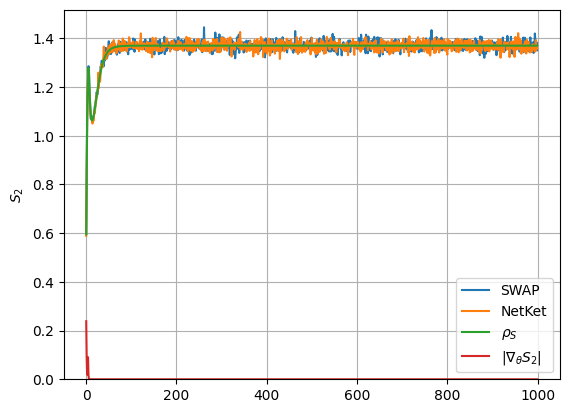

In [173]:
#Comprobar que la derivada del gradiente funciona
#Se busca el estado que maximiza S₂, en nuestro caso max(S₂)=ln(4)

partition = list(range(N))  
# sampler = nk.sampler.MetropolisLocal(hi_extended)
sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
model = RBM_Z2(alpha=8, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=20000)
vstate.init_parameters
# optimizer = optax.sgd(learning_rate=0.8, momentum=0.9)
# optimizer = optax.adam(learning_rate=optax.schedules.linear_onecycle_schedule(1000, 0.5, 0.3, 0.85, 10, 100))
# optimizer = optax.adamw(learning_rate=0.1, weight_decay=1e-2)
# optimizer = optax.chain(
#     optax.clip_by_global_norm(1.0),
#     optax.sgd(learning_rate=optax.schedules.cosine_decay_schedule(init_value=1.0,decay_steps=1000,alpha=0.01), 
#               momentum=0.9, nesterov=True)
# )
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam( 
        learning_rate=optax.warmup_cosine_decay_schedule(
            init_value=0.01,           # Empieza en 0.2
            peak_value=1,           # LR máximo (fase exploratoria)
            warmup_steps=300,         # steps subiendo
            decay_steps=1000,         # 1000 steps total
            end_value=0.1           # LR final (refinamiento)
        ),
        b1=0.9,                       # Momentum (default)
        b2=0.999                      # Segundo momento (default)
    )
)
# optimizer = optax.chain(
#     optax.clip_by_global_norm(1.0),
#     optax.adamw(  
#         learning_rate=optax.warmup_cosine_decay_schedule(
#             init_value=0.0,           # Empieza en 0
#             peak_value=0.5,           # LR máximo (fase exploratoria)
#             warmup_steps=100,         # 100 steps subiendo
#             decay_steps=1000,         # 1000 steps total
#             end_value=0.001           # LR final (refinamiento)
#         ),
#         weight_decay=1e-4,            # Regularización suave
#         b1=0.9,                       # Momentum (default)
#         b2=0.999                      # Segundo momento (default)
#     )
# )
opt_state = optimizer.init(vstate.parameters)

S2_history_swap = []
S2_history_nk = []
S2_history_trace = []
S2_grad_history= []

S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

for step in range(1000):
    S2, S2_grad_2 = renyi2_entropy_and_grad_sampled(vstate, partition, 10000, key=step)
    # S2_grad_2 = renyi2_grad_only_stable(vstate, partition, 10000, key=step)
    # S2, S2_grad_2 = renyi2_entropy_and_grad_stable(vstate, partition, 10000, key=step)
    # S2, S2_grad_2 = renyi2_entropy_and_grad_averaged(vstate, partition, 1008, step, 10)
    # S2, S2_grad_2 = renyi2_value_and_grad(vstate, N, partition, 10000, key=step)
    # S2, S2_grad_2 = renyi2_value_and_grad2(vstate, hi_extended, partition, 200000)
    S2_nk = vstate.expect(S2_obs).mean.real*np.log(2)
    S2_trace = renyi2_entropy_exact(vstate, partition)[0]
    S2_grad = jnp.linalg.norm(nk.jax.tree_ravel(S2_grad_2)[0])
    
    S_grad = jax.tree_util.tree_map(
        lambda grad_S2:  - grad_S2,
        S2_grad_2
    )
    
    updates, opt_state = optimizer.update(S_grad, opt_state, vstate.parameters)
    vstate.parameters = optax.apply_updates(vstate.parameters, updates)

    S2_history_swap.append(S2)
    S2_history_nk.append(S2_nk)
    S2_history_trace.append(S2_trace)
    S2_grad_history.append(S2_grad)
    a = vstate.expect_and_grad(H_extended)
    
    if step % 20 == 0:
        grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(S_grad)[0])
        print(f"Step {step}: S₂(SWAP)={S2:.6f}, S₂(NK)={S2_nk:.6f}, S₂(ρₛ)={S2_trace:.6f}, |∇S₂| = {S2_grad:.8f}")

plt.plot(S2_history_swap, label="SWAP")
plt.plot(S2_history_nk, label="NetKet")
plt.plot(S2_history_trace, label=r"$\rho_S$")
plt.plot(S2_grad_history, label=r"$|\nabla_\theta S_2$|")
plt.ylabel(r"$S_2$")
plt.ylim(0,)
plt.grid()
plt.legend()
plt.show

Número total de parámetros escalares: 840
Generando landscape 2D...
  Progreso: 0/30
  Progreso: 5/30
  Progreso: 10/30
  Progreso: 15/30
  Progreso: 20/30
  Progreso: 25/30


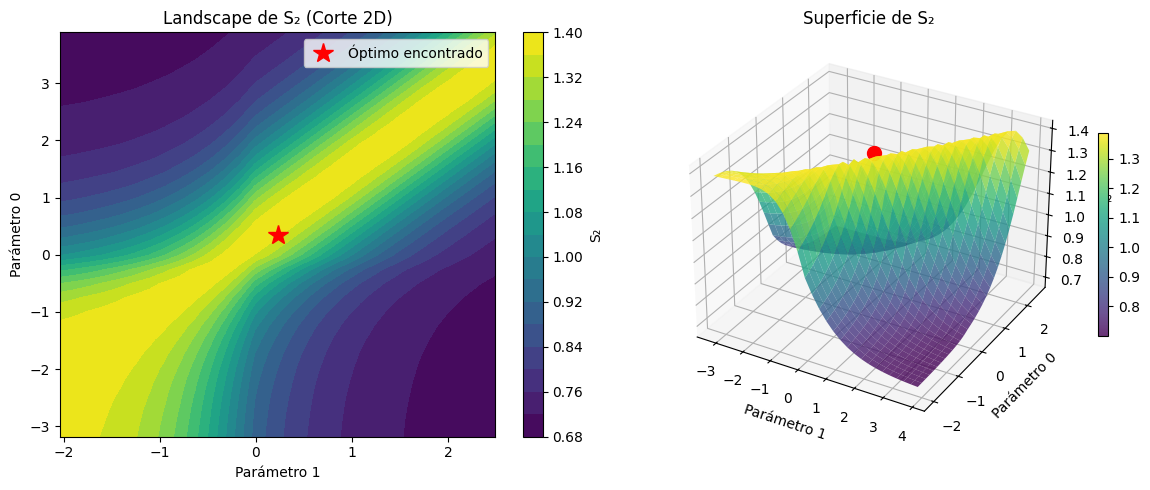


Generando cortes 1D...
  Completado parámetro 0/4
  Completado parámetro 1/4
  Completado parámetro 2/4
  Completado parámetro 3/4


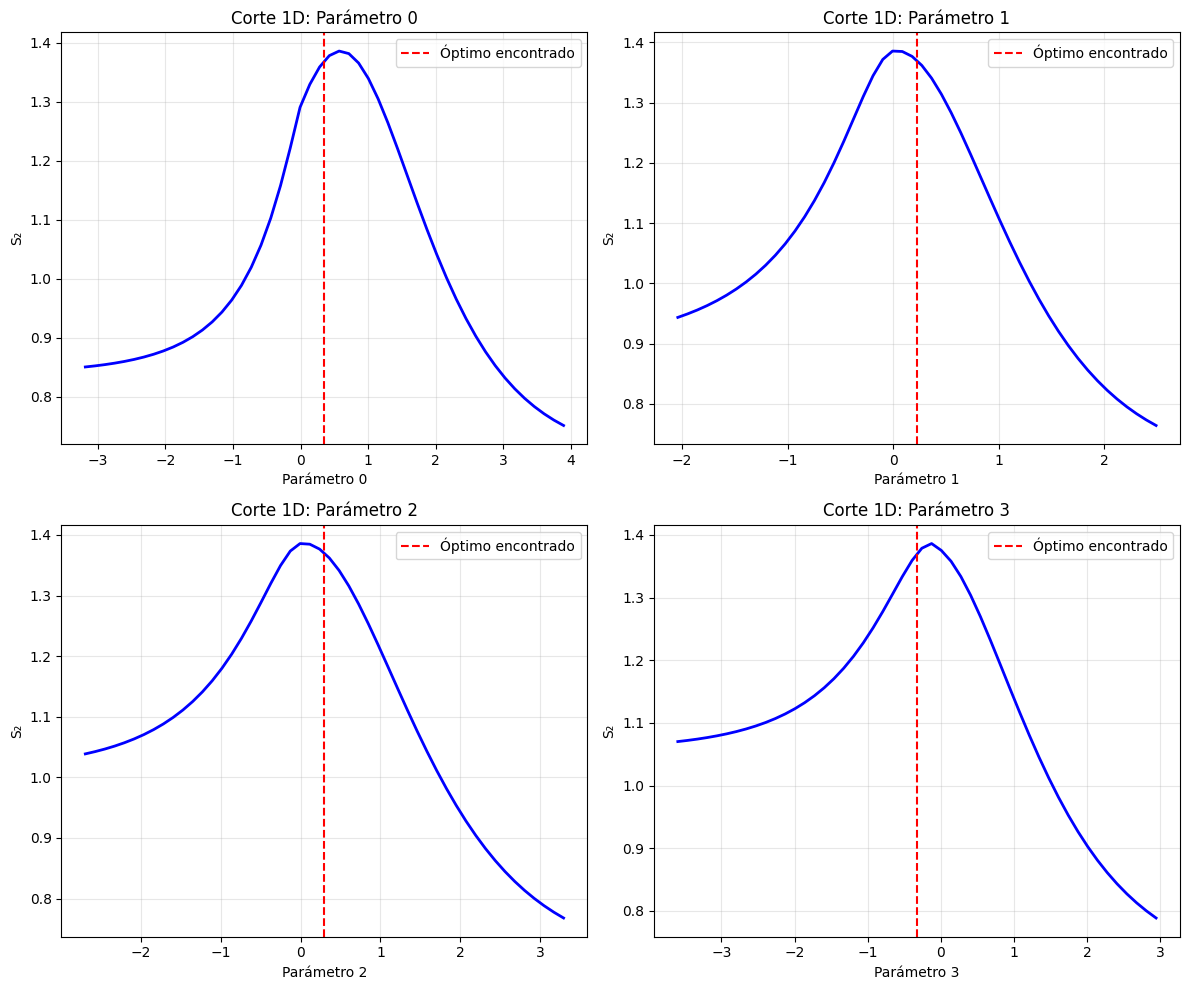

In [177]:
def visualize_s2_landscape(vstate, partition, optimal_params, n_samples=10000):
    """
    Visualiza el landscape de S₂ alrededor de los parámetros óptimos.
    
    Args:
        vstate: Estado variacional
        partition: Partición para calcular entrelazamiento
        optimal_params: Parámetros óptimos encontrados
        n_samples: Número de muestras para calcular S₂
    """
    
    # Aplanar parámetros completamente (incluyendo arrays internos)
    flat_params, tree_def = jax.tree_util.tree_flatten(optimal_params)
    
    # Aplanar completamente todos los arrays a escalares individuales
    all_scalars = []
    param_shapes = []
    param_indices = []  # (array_idx, element_idx)
    
    for i, param in enumerate(flat_params):
        if isinstance(param, (jnp.ndarray, np.ndarray)):
            param_flat = param.flatten()
            for j, scalar in enumerate(param_flat):
                all_scalars.append(float(scalar))
                param_shapes.append(param.shape)
                param_indices.append((i, j))
        else:
            all_scalars.append(float(param))
            param_shapes.append(())
            param_indices.append((i, -1))
    
    n_params = len(all_scalars)
    print(f"Número total de parámetros escalares: {n_params}")
    
    # Seleccionar dos parámetros escalares para explorar
    param_idx_1 = 0
    param_idx_2 = min(1, n_params - 1)
    
    # Definir rangos de exploración 
    param_1_opt = all_scalars[param_idx_1]
    param_2_opt = all_scalars[param_idx_2]
    
    range_factor = 10
    range_abs = max(abs(param_1_opt), 0.1)  # Evitar rangos de cero
    param_1_range = np.linspace(
        param_1_opt - range_factor * range_abs,
        param_1_opt + range_factor * range_abs,
        30
    )
    range_abs = max(abs(param_2_opt), 0.1)
    param_2_range = np.linspace(
        param_2_opt - range_factor * range_abs,
        param_2_opt + range_factor * range_abs,
        30
    )
    
    # ========== CORTE 2D ==========
    print("Generando landscape 2D...")
    S2_landscape = np.zeros((len(param_1_range), len(param_2_range)))
    
    for i, p1 in enumerate(param_1_range):
        for j, p2 in enumerate(param_2_range):
            # Crear nueva configuración de parámetros
            new_scalars = all_scalars.copy()
            new_scalars[param_idx_1] = p1
            new_scalars[param_idx_2] = p2
            
            # Reconstruir estructura de parámetros
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1
            
            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params
            
            # Calcular S₂
            # S2 = renyi2_entropy_sampled(vstate, N, partition, n_samples)
            S2 = renyi2_entropy_exact(vstate, partition)[0]
            S2_landscape[i, j] = S2
        
        if i % 5 == 0:
            print(f"  Progreso: {i}/{len(param_1_range)}")
    
    # Visualizar corte 2D
    fig = plt.figure(figsize=(12, 5))
    
    # Subplot 1: Mapa de calor
    ax1 = fig.add_subplot(121)
    im = ax1.contourf(param_2_range, param_1_range, S2_landscape, 
                      levels=20, cmap='viridis')
    ax1.plot(param_2_opt, param_1_opt, 'r*', markersize=15, 
             label='Óptimo encontrado')
    ax1.set_xlabel(f'Parámetro {param_idx_2}')
    ax1.set_ylabel(f'Parámetro {param_idx_1}')
    ax1.set_title('Landscape de S₂ (Corte 2D)')
    ax1.legend()
    plt.colorbar(im, ax=ax1, label='S₂')
    
    # Subplot 2: Superficie 3D
    ax2 = fig.add_subplot(122, projection='3d')
    P1, P2 = np.meshgrid(param_2_range, param_1_range)
    surf = ax2.plot_surface(P2, P1, S2_landscape, cmap='viridis', 
                            alpha=0.8, edgecolor='none')
    ax2.scatter([param_2_opt], [param_1_opt], [S2_landscape[len(param_1_range)//2, len(param_2_range)//2]], 
                color='red', s=100, label='Óptimo')
    ax2.set_xlabel(f'Parámetro {param_idx_2}')
    ax2.set_ylabel(f'Parámetro {param_idx_1}')
    ax2.set_zlabel('S₂')
    ax2.set_title('Superficie de S₂')
    plt.colorbar(surf, ax=ax2, shrink=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # ========== CORTES 1D ==========
    print("\nGenerando cortes 1D...")
    
    # Seleccionar algunos parámetros importantes para visualizar
    params_to_plot = min(4, n_params)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for idx in range(params_to_plot):
        param_opt = all_scalars[idx]
        range_abs = max(abs(param_opt), 0.1)
        param_range = np.linspace(
            param_opt - range_factor * range_abs,
            param_opt + range_factor * range_abs,
            50
        )
        
        S2_values = []
        for p in param_range:
            new_scalars = all_scalars.copy()
            new_scalars[idx] = p
            
            # Reconstruir estructura de parámetros
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1
            
            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params
            
            # S2, _ = renyi2_entropy_and_grad_sampled(vstate, partition, n_samples, key=idx*1000+len(S2_values))
            S2 = renyi2_entropy_exact(vstate, partition)[0]
            S2_values.append(S2)
        
        axes[idx].plot(param_range, S2_values, 'b-', linewidth=2)
        axes[idx].axvline(param_opt, color='r', linestyle='--', 
                         label='Óptimo encontrado')
        axes[idx].set_xlabel(f'Parámetro {idx}')
        axes[idx].set_ylabel('S₂')
        axes[idx].set_title(f'Corte 1D: Parámetro {idx}')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()
        
        print(f"  Completado parámetro {idx}/{params_to_plot}")
    
    plt.tight_layout()
    plt.show()
    
    # Restaurar parámetros óptimos
    vstate.parameters = optimal_params

optimal_params = vstate.parameters
visualize_s2_landscape(vstate, partition, optimal_params, n_samples=10000)


In [152]:
state_vector = vstate.to_array()
# print("Vector de estado completo:")
# print(state_vector)

# Obtener estados individuales con sus amplitudes
basis_states = hi_extended.all_states()
for i, state in enumerate(basis_states):
    amplitude = state_vector[i]
#     print(f"Estado {state}: {amplitude:.3f}")

# Calcular probabilidades
probabilities = jnp.abs(state_vector)**2
for i, state in enumerate(basis_states):
    print(f"P(|{state}⟩) = {probabilities[i]:.3f}")

prob00= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==-1 and state[1]==-1)
print(f"\nP(|-1-1⟩): {prob00:.3f}")
prob11= sum(probabilities[i] for i, state in enumerate(basis_states) if state[0]==1 and state[1]==1)
print(f"\nP(|11⟩): {prob11:.3f}")
p01= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==-1 and state[1]==1))
print(f"\nP(|-11⟩): {p01:.3f}")
p10= sum(probabilities[i] for i, state in enumerate(basis_states) if (state[0]==1 and state[1]==-1))
print(f"\nP(|1-1⟩): {p10:.3f}")

P(|[1 1 1 1]⟩) = 0.027
P(|[ 1  1  1 -1]⟩) = 0.001
P(|[ 1  1 -1  1]⟩) = 0.000
P(|[ 1  1 -1 -1]⟩) = 0.000
P(|[ 1 -1  1  1]⟩) = 0.000
P(|[ 1 -1  1 -1]⟩) = 0.472
P(|[ 1 -1 -1  1]⟩) = 0.000
P(|[ 1 -1 -1 -1]⟩) = 0.000
P(|[-1  1  1  1]⟩) = 0.000
P(|[-1  1  1 -1]⟩) = 0.000
P(|[-1  1 -1  1]⟩) = 0.472
P(|[-1  1 -1 -1]⟩) = 0.000
P(|[-1 -1  1  1]⟩) = 0.000
P(|[-1 -1  1 -1]⟩) = 0.000
P(|[-1 -1 -1  1]⟩) = 0.001
P(|[-1 -1 -1 -1]⟩) = 0.027

P(|-1-1⟩): 0.028

P(|11⟩): 0.028

P(|-11⟩): 0.472

P(|1-1⟩): 0.472


In [ ]:
#Minimizar F = <H> - TS₂ mediante ADAM o SGD
partition = list(range(N))  
# Estado variacional
g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=N+N_ancilla)
# sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=1008)
# optimizer = optax.adam(learning_rate=0.003)
optimizer = optax.sgd(learning_rate=0.05)
opt_state = optimizer.init(vstate.parameters)

# ========== LOOP DE OPTIMIZACIÓN ==========
T = 2
energy_history = []
S2_history = []
F_history = []

S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

for step in range(1000):
    E, E_grad = vstate.expect_and_grad(H_extended)
    S21_2, S2_grad_2 = renyi2_entropy_and_grad_sampled(vstate, partition, 1008, key=step)
    # S21_2, S2_grad_2 = renyi2_value_and_grad(vstate, N, partition, 1008, key=step)
    # S21_2, S2_grad_2 = renyi2_value_and_grad2(vstate, hi_extended, partition, 1008)
    S21_22 = vstate.expect(S2_obs).mean
    # S21_22 = renyi2_entropy_sampled(vstate, N, partition, 1008, key=step)
    
    # 3. Combinar gradientes: ∇F = ∇E - T * ∇S₂
    F_grad = jax.tree_util.tree_map(
        lambda grad_E, grad_S2: grad_E - T * grad_S2,
        E_grad, S2_grad_2
    )
    
    # 4. Actualizar parámetros con Adam (optax)
    updates, opt_state = optimizer.update(F_grad, opt_state, vstate.parameters)
    vstate.parameters = optax.apply_updates(vstate.parameters, updates)
    
    # 5. Calcular free energy
    F = E.mean.real - T * S21_2
    
    # 6. Guardar historia
    energy_history.append(E.mean.real)
    S2_history.append(S21_2)
    F_history.append(F)
    
    # 7. Log cada 20 pasos
    if step % 20 == 0:
        grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(F_grad)[0])
        print(f"Step {step}: E={E.mean.real:.6f}, S₂={S21_2:.6f}, S₂={S21_22:.6f}, F={F:.6f}, |∇F|={grad_norm:.6f}")

Step 0: E=-3.226312, S₂=0.000045, S₂=0.000028, F=-3.226401, |∇F|=0.184977
Step 20: E=-3.496153, S₂=-0.006035, S₂=-0.008546, F=-3.484083, |∇F|=0.900320
Step 40: E=-3.597852, S₂=0.016486, S₂=0.023381, F=-3.630824, |∇F|=0.027074
Step 60: E=-3.597720, S₂=0.023642, S₂=0.013128, F=-3.645004, |∇F|=0.250501
Step 80: E=-3.596730, S₂=0.012555, S₂=0.015357, F=-3.621840, |∇F|=0.189293
Step 100: E=-3.597977, S₂=0.022548, S₂=0.019416, F=-3.643072, |∇F|=0.126281
Step 120: E=-3.598017, S₂=0.016000, S₂=0.012796, F=-3.630017, |∇F|=0.036542
Step 140: E=-3.597470, S₂=0.014948, S₂=0.010755, F=-3.627366, |∇F|=0.231631
Step 160: E=-3.598199, S₂=0.022566, S₂=0.015393, F=-3.643330, |∇F|=0.126194
Step 180: E=-3.597333, S₂=0.020646, S₂=0.012924, F=-3.638625, |∇F|=0.114697
Step 200: E=-3.595169, S₂=0.012910, S₂=0.010004, F=-3.620990, |∇F|=0.200866
Step 220: E=-3.599140, S₂=0.013768, S₂=0.010868, F=-3.626676, |∇F|=0.053006
Step 240: E=-3.599772, S₂=0.017002, S₂=0.006921, F=-3.633776, |∇F|=0.168164
Step 260: E=-3.5

In [160]:
#Minimizar F = <H> - TS₂ en función de T para comparar con "Ancilla_exact.ipynb"

# g = nk.graph.Chain(length=N+N_ancilla, pbc=False)
# sampler = nk.sampler.MetropolisExchange(hi_extended, graph=g, d_max=4)
sampler = nk.sampler.ExactSampler(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)

T_array = np.linspace(0, 2, 10)  

energy_results = []
entropy_results = []  
entropy_netket_results = []  
free_energy_results = []
all_histories = []

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")
    vstate = nk.vqs.MCState(sampler, model, n_samples=20000)
    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adam(  
            learning_rate=optax.warmup_cosine_decay_schedule(
                init_value=0,           # Empieza en 0
                peak_value=0.1,           # LR máximo (fase exploratoria)
                warmup_steps=300,         # steps subiendo
                decay_steps=1000,         # 1000 steps total
                end_value=0.05           # LR final (refinamiento)
            ),
            b1=0.9,                       # Momentum (default)
            b2=0.999                      # Segundo momento (default)
        )
    )
    # optimizer = optax.adam(learning_rate=0.1)
    opt_state = optimizer.init(vstate.parameters)
    
    S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended,partition=partition)
    
    energy_history = []
    entropy_history = []
    entropy_netket_history = []
    F_history = []

    best_F = np.inf
    best_energy = None
    best_entropy = None
    best_entropy_netket = None
    best_step = None

    n_steps = 1000
    
    for step in range(n_steps):
        E, E_grad = vstate.expect_and_grad(H_extended)
        
        S2_val, S2_grad = renyi2_entropy_and_grad_sampled(
            vstate, 
            subsystem_sites=partition,
            n_samples=10000,
            key=step 
        )
        S2_netket = vstate.expect(S2_obs).mean.real*np.log(2)
        
        F_grad = jax.tree_util.tree_map(
            lambda grad_E, grad_S2: grad_E - T * grad_S2,
            E_grad, S2_grad
        )
        
        updates, opt_state = optimizer.update(F_grad, opt_state, vstate.parameters)
        vstate.parameters = optax.apply_updates(vstate.parameters, updates)
        
        F = E.mean.real - T * S2_val
        
        energy_history.append(E.mean.real)
        entropy_history.append(S2_val)
        entropy_netket_history.append(S2_netket)
        F_history.append(F)

        if F < best_F:
            best_F = F
            best_energy = E.mean.real
            best_entropy = S2_val
            best_entropy_netket = S2_netket
            best_step = step

        
        if step % 50 == 0:
            grad_norm = jnp.linalg.norm(nk.jax.tree_ravel(F_grad)[0])
            print(f"  Step {step}: E={E.mean.real:.4f}, S₂={S2_val:.4f}, "
                  f"S₂(NK)={S2_netket:.4f}, F={F:.4f}, |∇F|={grad_norm:.4f}")
    
    final_energy = best_energy
    final_entropy = best_entropy
    final_entropy_netket = best_entropy_netket
    final_F = best_F
    
    energy_results.append(final_energy)
    entropy_results.append(final_entropy)
    entropy_netket_results.append(final_entropy_netket)
    free_energy_results.append(final_F)
    
    all_histories.append({
        'T': T,
        'energy': energy_history,
        'entropy': entropy_history,
        'entropy_netket': entropy_netket_history,
        'free_energy': F_history
    })
    
    print(f"  Mejor resultado: E={final_energy:.4f}, S₂={final_entropy:.4f}, "
          f"F={final_F:.4f}")
    print(f"  Diferencia S₂: {abs(final_entropy - final_entropy_netket):.6f}")

# ========== VISUALIZACIÓN ==========
plt.figure(figsize=(15, 10))

# 1. Resultados finales vs temperatura
plt.subplot(2, 3, 1)
plt.plot(T_array, energy_results, 'o-', label=r'$\langle H \rangle$')
plt.xlabel('T')
plt.ylabel('Energía')
plt.title('Energía vs Temperatura')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(T_array, entropy_results, 's-', label='S₂ (nuestra)')
plt.plot(T_array, entropy_netket_results, '^--', label='S₂ (NetKet)', alpha=0.7)
plt.xlabel('T')
plt.ylabel('S₂')
plt.title('Entropía de Rényi-2 vs Temperatura')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(T_array, free_energy_results, 'd-', label='F = E - TS₂')
plt.xlabel('T')
plt.ylabel('F')
plt.title('Energía Libre vs Temperatura')
plt.grid(True, alpha=0.3)

# 2. Evolución durante optimización para algunas T seleccionadas
selected_T_indices = [0, len(T_array)//2, -1] 
for idx in selected_T_indices:
    T_val = T_array[idx]
    hist = all_histories[idx]
    
    plt.subplot(2, 3, 4)
    plt.plot(hist['energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('Energía')
    plt.title('Evolución de Energía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 5)
    plt.plot(hist['entropy'], label=f'T={T_val:.2f}')
    plt.plot(hist['entropy_netket'], '--', alpha=0.5)
    plt.xlabel('Paso de optimización')
    plt.ylabel('S₂')
    plt.title('Evolución de Entropía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 6)
    plt.plot(hist['free_energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('F')
    plt.title('Evolución de Energía Libre')
    plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4).legend()
plt.tight_layout()
plt.show()

# ========== RESUMEN ==========
print("\n=== RESUMEN DE RESULTADOS ===")
print("Temperatura | Energía | S₂ (nuestra) | S₂ (NetKet) | Energía Libre")
print("-" * 70)
for i, T in enumerate(T_array):
    print(f"{T:10.3f} | {energy_results[i]:8.4f} | {entropy_results[i]:12.4f} | "
          f"{entropy_netket_results[i]:11.4f} | {free_energy_results[i]:13.4f}")

Temperaturas:   0%|          | 0/10 [00:00<?, ?it/s]


=== Temperatura T = 0.000 ===
  Step 0: E=-2.7750, S₂=0.6506, S₂(NK)=0.6331, F=-2.7750, |∇F|=4.9020


Temperaturas:   0%|          | 0/10 [00:07<?, ?it/s]


KeyboardInterrupt: 

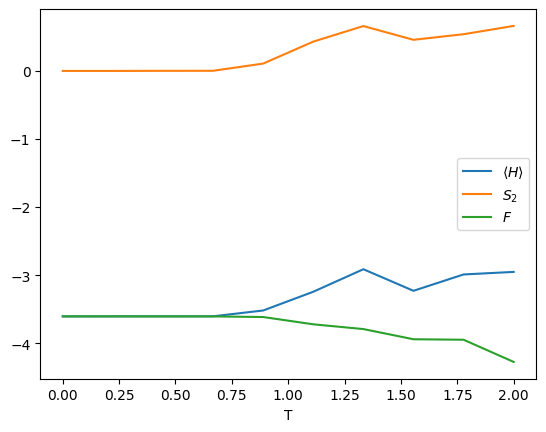

In [57]:
plt.plot(T_array, energy_results, label=r"$\langle H \rangle $")
plt.plot(T_array, entropy_results, label=r"$S_2$")
plt.plot(T_array, free_energy_results, label=r"$F$")
plt.xlabel("T")
plt.legend()
plt.show()